# 03 — Fine-tuning & hyperparameter search

Fine-tunes `bert-base-uncased` and `roberta-base` on MELD under an identical
protocol and runs a 12-run hyperparameter grid.

Covers assignment **steps 5, 6, 7**.

The training machinery lives in `src/training.py` rather than in this
notebook, for two reasons: the grid is hours of GPU work and must survive an
interrupted session, and the same code should be runnable headless
(`python src/training.py`). Every finished run is appended to
`results/hparam_search.csv` immediately, and `run_grid()` skips any
configuration already logged — so **this notebook is idempotent**: re-running
it re-renders the analysis without repeating completed GPU work.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

sys.path.insert(0, str(Path.cwd().parent / "src"))
import training  # noqa: E402
import utils  # noqa: E402

utils.ensure_dirs()
utils.set_seed()
sns.set_theme(style="whitegrid", context="notebook")

print(f"torch {torch.__version__} | CUDA {torch.version.cuda}")
print(f"device: {torch.cuda.get_device_name(0)}")
print(f"bf16 supported: {torch.cuda.is_bf16_supported()}")

torch 2.13.0+cu132 | CUDA 13.2
device: NVIDIA GeForce RTX 5070
bf16 supported: True


## 1. Training setup (steps 5–6)

**Full fine-tuning** — every parameter of the encoder is updated, plus a
freshly initialized 7-way classification head over the pooled `[CLS]`/`<s>`
representation.

The loss is a **class-weighted cross-entropy** (`WeightedTrainer` in
`src/training.py`), using the inverse-frequency weights computed on train in
notebook 02. Without it, the 17.6× imbalance pushes the model toward
answering "neutral" to everything.

Both models get an **identical protocol** — same splits, same weights, same
grid, same seed, same selection rule — so any difference between them is
attributable to pretraining rather than to unequal tuning effort.

In [2]:
print("class weights (by label id):")
for name, w in zip(utils.LABEL_NAMES, utils.load_class_weights()):
    print(f"  {name:9s} {w:.3f}")

print(f"\nfixed across the grid: warmup_ratio={training.WARMUP_RATIO}, "
      f"weight_decay={training.WEIGHT_DECAY}, max_epochs={training.MAX_EPOCHS}")
print(f"max_length={utils.MAX_LENGTH} (dynamic padding via DataCollatorWithPadding)")

class weights (by label id):
  neutral   0.303
  joy       0.819
  surprise  1.184
  anger     1.287
  sadness   2.089
  disgust   5.266
  fear      5.325

fixed across the grid: warmup_ratio=0.06, weight_decay=0.01, max_epochs=5
max_length=128 (dynamic padding via DataCollatorWithPadding)


## 2. The grid (step 7)

| Hyperparameter | Values | Justification |
|---|---|---|
| learning rate | 1e-5, 2e-5, 5e-5 | spans the range recommended by the BERT paper for fine-tuning; above ~5e-5 fine-tuning tends to diverge, below ~1e-5 it underfits within a few epochs |
| batch size | 16, 32 | BERT-paper defaults; both fit 12 GB at seq len 128 in bf16. Crossed with lr rather than tuned separately because the two interact (larger batches average gradients over more examples, tolerating larger steps) |
| epochs | ≤5, best epoch chosen on dev | MELD is small (~10k), so overfitting typically appears by epoch 3–4. Selecting the best epoch on dev makes epochs a *tuned* quantity without spending a separate run per value |

3 learning rates × 2 batch sizes = **6 runs per model, 12 total**.

`warmup_ratio=0.06` and `weight_decay=0.01` are **held fixed** so the grid
isolates the lr × batch-size interaction. Warmup stabilizes the first few
hundred steps, when the randomly initialized head sends large gradients back
into the pretrained encoder; the decay value is the standard BERT default.

**Selection uses dev only — the test split is not touched in this notebook.**

In [3]:
# Resumable: skips configurations already present in results/hparam_search.csv.
results = training.run_grid()
results.sort_values("dev_weighted_f1", ascending=False)

grid: 12 runs, 12 already complete


tokenizing:   0%|          | 0/9989 [00:00<?, ? examples/s]

tokenizing:   0%|          | 0/1109 [00:00<?, ? examples/s]

skip  bert lr=1e-05 bs=16 (already logged)
skip  bert lr=1e-05 bs=32 (already logged)
skip  bert lr=2e-05 bs=16 (already logged)
skip  bert lr=2e-05 bs=32 (already logged)
skip  bert lr=5e-05 bs=16 (already logged)
skip  bert lr=5e-05 bs=32 (already logged)


tokenizing:   0%|          | 0/9989 [00:00<?, ? examples/s]

tokenizing:   0%|          | 0/1109 [00:00<?, ? examples/s]

skip  roberta lr=1e-05 bs=16 (already logged)
skip  roberta lr=1e-05 bs=32 (already logged)
skip  roberta lr=2e-05 bs=16 (already logged)
skip  roberta lr=2e-05 bs=32 (already logged)
skip  roberta lr=5e-05 bs=16 (already logged)
skip  roberta lr=5e-05 bs=32 (already logged)


,model,model_name,learning_rate,batch_size,max_epochs,best_epoch,dev_weighted_f1,dev_macro_f1,dev_accuracy,dev_loss,wall_time_s,epoch_f1_trace
2,bert,bert-base-uncased,0.00002,16,5,3,0.6030,0.5009,0.5978,1.4929,140.1,0.5618;0.5651;0.6030;0.5903;0.5865
4,bert,bert-base-uncased,0.00005,16,5,3,0.5972,0.4840,0.6005,1.7184,134.7,0.5543;0.5592;0.5972;0.5840;0.5817
5,bert,bert-base-uncased,0.00005,32,5,5,0.5919,0.4625,0.5951,2.1192,73.1,0.5435;0.5649;0.5696;0.5906;0.5919
0,bert,bert-base-uncased,0.00001,16,5,4,0.5879,0.4636,0.5816,1.4534,141.5,0.5674;0.5755;0.5726;0.5879;0.5834
10,roberta,roberta-base,0.00005,16,5,4,0.5843,0.4468,0.5744,1.7748,144.8,0.5049;0.5498;0.5543;0.5843;0.5704
9,roberta,roberta-base,0.00002,32,5,1,0.5826,0.4172,0.5816,1.6083,76.7,0.5826;0.5350;0.5472;0.5677;0.5727
3,bert,bert-base-uncased,0.00002,32,5,5,0.5805,0.4681,0.5726,1.5297,72.5,0.5718;0.5564;0.5629;0.5755;0.5805
8,roberta,roberta-base,0.00002,16,5,4,0.5784,0.4453,0.5717,1.6626,143.6,0.5514;0.5563;0.5663;0.5784;0.5765
6,roberta,roberta-base,0.00001,16,5,5,0.5750,0.4565,0.5663,1.5093,138.7,0.5454;0.5332;0.5542;0.5660;0.5750
1,bert,bert-base-uncased,0.00001,32,5,5,0.5711,0.4424,0.5600,1.4218,78.3,0.5387;0.5596;0.5602;0.5709;0.5711


## 3. Search results

In [4]:
table = results[
    ["model", "learning_rate", "batch_size", "best_epoch",
     "dev_weighted_f1", "dev_macro_f1", "dev_accuracy", "wall_time_s"]
].sort_values(["model", "learning_rate", "batch_size"])
table

,model,learning_rate,batch_size,best_epoch,dev_weighted_f1,dev_macro_f1,dev_accuracy,wall_time_s
0,bert,0.00001,16,4,0.5879,0.4636,0.5816,141.5
1,bert,0.00001,32,5,0.5711,0.4424,0.5600,78.3
2,bert,0.00002,16,3,0.6030,0.5009,0.5978,140.1
3,bert,0.00002,32,5,0.5805,0.4681,0.5726,72.5
4,bert,0.00005,16,3,0.5972,0.4840,0.6005,134.7
5,bert,0.00005,32,5,0.5919,0.4625,0.5951,73.1
6,roberta,0.00001,16,5,0.5750,0.4565,0.5663,138.7
7,roberta,0.00001,32,5,0.5550,0.4339,0.5419,75.7
8,roberta,0.00002,16,4,0.5784,0.4453,0.5717,143.6
9,roberta,0.00002,32,1,0.5826,0.4172,0.5816,76.7


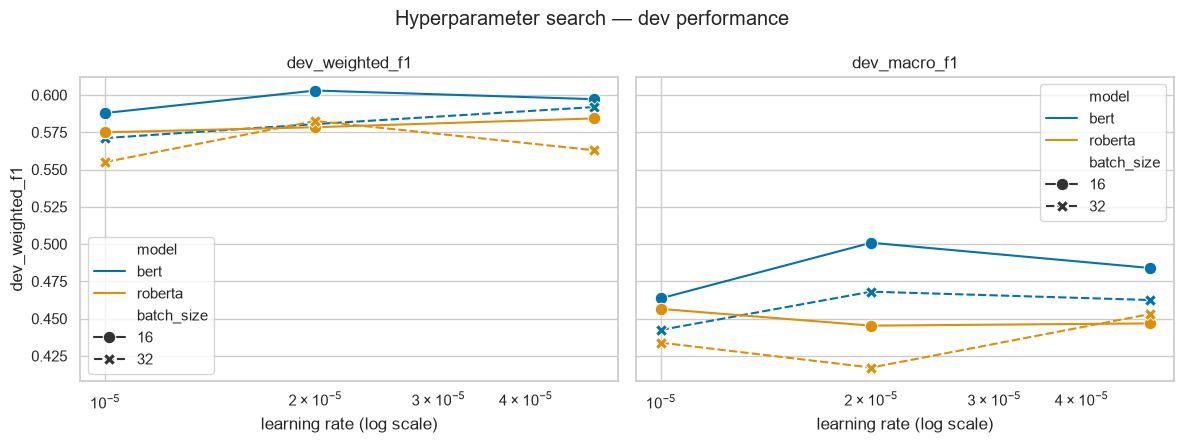

In [5]:
# Dev weighted F1 as a function of lr, one line per (model, batch size).
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, metric in zip(axes, ["dev_weighted_f1", "dev_macro_f1"]):
    sns.lineplot(
        data=results, x="learning_rate", y=metric, hue="model", style="batch_size",
        markers=True, dashes=True, ax=ax, palette="colorblind", markersize=9,
    )
    ax.set_xscale("log")
    ax.set_title(metric)
    ax.set_xlabel("learning rate (log scale)")
fig.suptitle("Hyperparameter search — dev performance")
fig.tight_layout()
fig.savefig(utils.FIGURES / "hparam_search.png", dpi=150)
plt.show()

### Which hyperparameter mattered more?

Spread of dev weighted F1 attributable to each knob: the range across
learning rates (holding model/batch fixed) versus across batch sizes
(holding model/lr fixed).

In [6]:
lr_spread = results.groupby(["model", "batch_size"])["dev_weighted_f1"].agg(lambda s: s.max() - s.min())
bs_spread = results.groupby(["model", "learning_rate"])["dev_weighted_f1"].agg(lambda s: s.max() - s.min())
print("dev weighted-F1 range across LEARNING RATES (per model+bs):")
print(lr_spread.round(4).to_string())
print(f"  mean spread: {lr_spread.mean():.4f}")
print("\ndev weighted-F1 range across BATCH SIZES (per model+lr):")
print(bs_spread.round(4).to_string())
print(f"  mean spread: {bs_spread.mean():.4f}")

dev weighted-F1 range across LEARNING RATES (per model+bs):
model    batch_size
bert     16            0.0151
         32            0.0208
roberta  16            0.0093
         32            0.0276
  mean spread: 0.0182

dev weighted-F1 range across BATCH SIZES (per model+lr):
model    learning_rate
bert     0.00001          0.0168
         0.00002          0.0225
         0.00005          0.0053
roberta  0.00001          0.0200
         0.00002          0.0042
         0.00005          0.0213
  mean spread: 0.0150


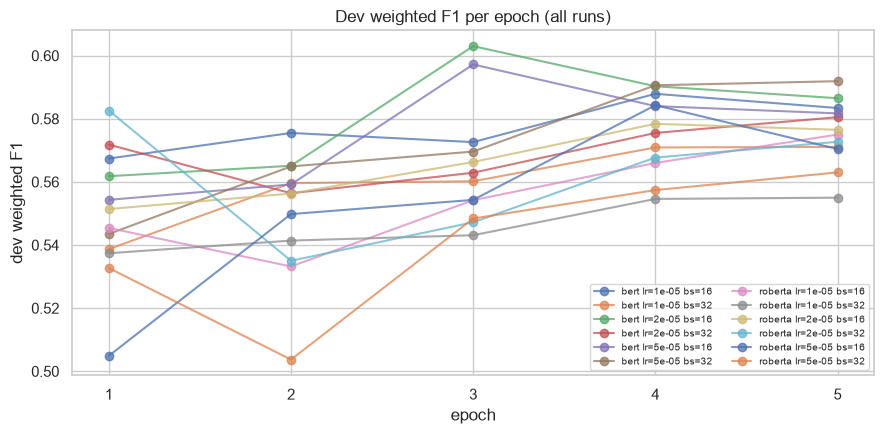

In [7]:
# Per-epoch dev F1 traces — shows where overfitting sets in.
fig, ax = plt.subplots(figsize=(9, 4.5))
for _, r in results.iterrows():
    trace = [float(x) for x in str(r["epoch_f1_trace"]).split(";")]
    ax.plot(range(1, len(trace) + 1), trace, marker="o", alpha=0.75,
            label=f"{r['model']} lr={r['learning_rate']:g} bs={int(r['batch_size'])}")
ax.set_xlabel("epoch")
ax.set_ylabel("dev weighted F1")
ax.set_title("Dev weighted F1 per epoch (all runs)")
ax.set_xticks(range(1, training.MAX_EPOCHS + 1))
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(utils.FIGURES / "epoch_traces.png", dpi=150)
plt.show()

## 4. Best configuration per model

The winning checkpoint per model is promoted to `checkpoints/{model}/best`
and the losing runs' checkpoints are deleted (they are large and
regenerable). Notebook 04 loads exactly these two.

In [8]:
best_configs = training.promote_best()
for model_key, cfg in best_configs.items():
    print(f"{model_key:8s} lr={cfg['learning_rate']:g} bs={cfg['batch_size']} "
          f"epoch={cfg['best_epoch']} -> dev weighted F1 {cfg['dev_weighted_f1']:.4f} "
          f"macro {cfg['dev_macro_f1']:.4f}")
best_configs

bert     lr=2e-05 bs=16 epoch=3 -> dev weighted F1 0.6030 macro 0.5009
roberta  lr=5e-05 bs=16 epoch=4 -> dev weighted F1 0.5843 macro 0.4468


{'bert': {'learning_rate': 2e-05,
  'batch_size': 16,
  'best_epoch': 3,
  'dev_weighted_f1': 0.603,
  'dev_macro_f1': 0.5009,
  'checkpoint': 'checkpoints\\bert\\best'},
 'roberta': {'learning_rate': 5e-05,
  'batch_size': 16,
  'best_epoch': 4,
  'dev_weighted_f1': 0.5843,
  'dev_macro_f1': 0.4468,
  'checkpoint': 'checkpoints\\roberta\\best'}}

In [9]:
results.to_csv(utils.RESULTS / "hparam_search.csv", index=False)
print("search table + best_configs.json written to results/")

search table + best_configs.json written to results/


## Summary

- 12 runs (2 models × 3 learning rates × 2 batch sizes), ≤5 epochs each, with
  the best epoch selected on dev weighted F1.
- Full search table logged to `results/hparam_search.csv` — a required
  deliverable for step 7.
- Best checkpoint per model promoted to `checkpoints/{model}/best`.
- Test split still untouched.

Next: `04_evaluation_comparison.py`.